In [20]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

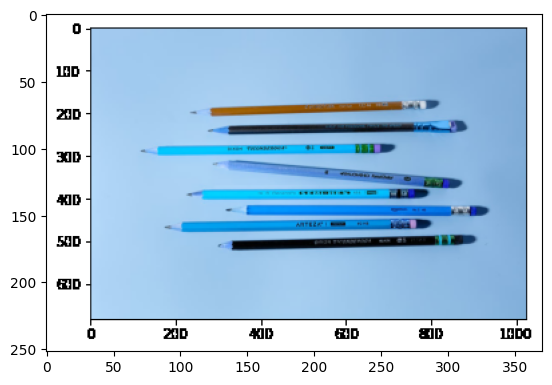

In [21]:
pencil = cv2.imread('pencil.png')
plt.imshow(pencil)

Filtered objects number is: 1


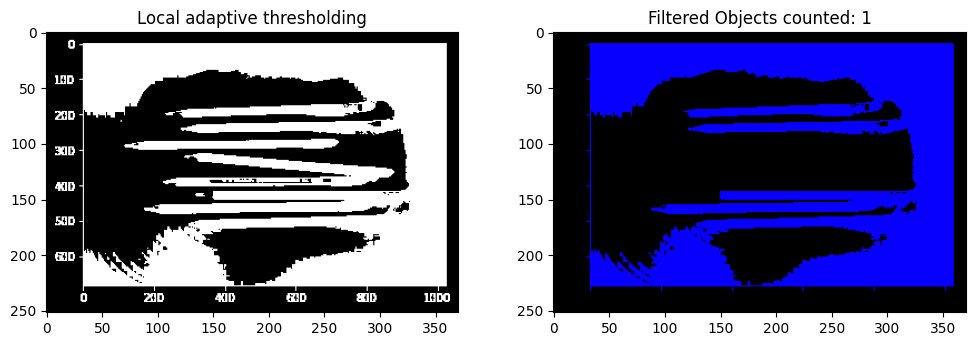

In [22]:
plt.figure(figsize=(12,8))
plt.subplot(221)
plt.title('Local adaptive thresholding')
plt.imshow(threshold, cmap='gray')

# Labeling with stats
ret, labels, stats, _ = cv2.connectedComponentsWithStats(threshold)

# Filter small areas (tune min_area based on your image)
min_area = 5000
filtered_labels = np.zeros_like(labels)

for i in range(1, ret):
    if stats[i, cv2.CC_STAT_AREA] >= min_area:
        filtered_labels[labels == i] = i

# Color map for visualization
label_hue = np.uint8(179 * filtered_labels / np.max(filtered_labels))
blank_ch = 255 * np.ones_like(label_hue)
labeled_img = cv2.merge([label_hue, blank_ch, blank_ch])
labeled_img = cv2.cvtColor(labeled_img, cv2.COLOR_HSV2BGR)
labeled_img[label_hue == 0] = 0

plt.subplot(222)
plt.title('Filtered Objects counted: ' + str(np.unique(filtered_labels)[1:].size))
plt.imshow(labeled_img)

print('Filtered objects number is:', np.unique(filtered_labels)[1:].size)
plt.show()


objects number is: 1


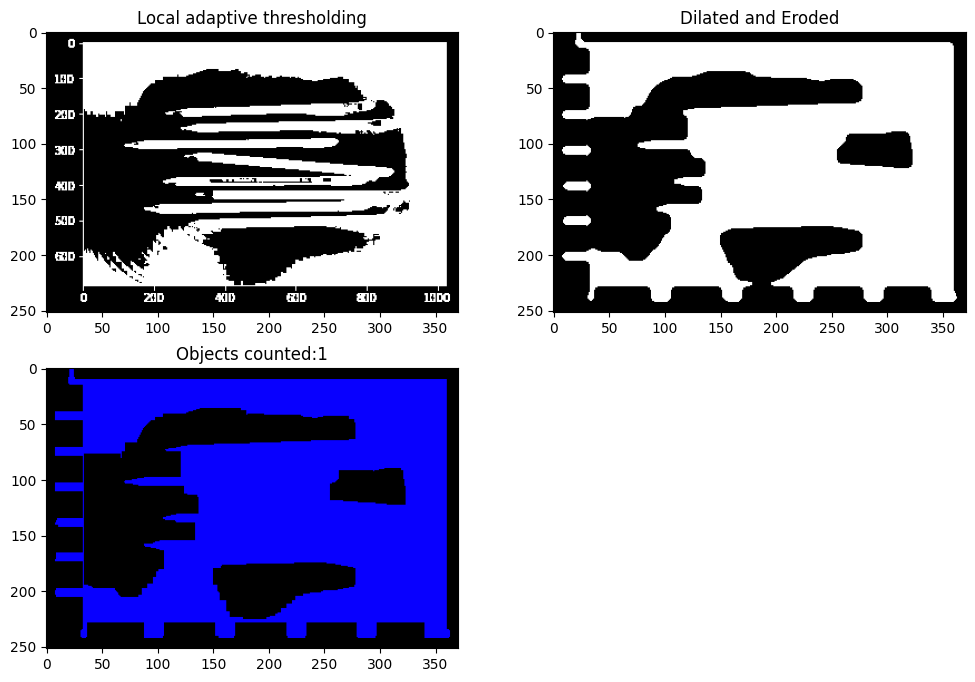

In [23]:
plt.figure(figsize=(12,8))
plt.subplot(221)
plt.title('Local adaptive thresholding')
plt.imshow(threshold, cmap='gray')

# We will use erosion and dillation technique 
# to connect the connected region in order to get on region per object

kernel =np.ones((15,15), np.uint8)
img_dilate= cv2.dilate(threshold, kernel, iterations=1)
img_erode= cv2.erode(img_dilate, kernel, iterations=1)

# clean all noise after dilation and erosion
img_eroded= cv2.medianBlur(img_erode, 7)
plt.subplot(222)
plt.title('Dilated and Eroded')
plt.imshow(img_eroded, cmap='gray')

# Labeling

ret, labels = cv2.connectedComponents(img_erode)
label_hue = np.uint8(179 * labels / np.max(labels))
blank_ch = 255 * np.ones_like(label_hue)
labeled_img = cv2.merge([label_hue, blank_ch, blank_ch])
labeled_img = cv2.cvtColor(labeled_img, cv2.COLOR_HSV2BGR)
labeled_img[label_hue == 0] = 0

plt.subplot(223)
plt.title('Objects counted:'+ str(ret-1))
plt.imshow(labeled_img)
print('objects number is:', ret-1)
plt.show()

Number of objects detected: 11


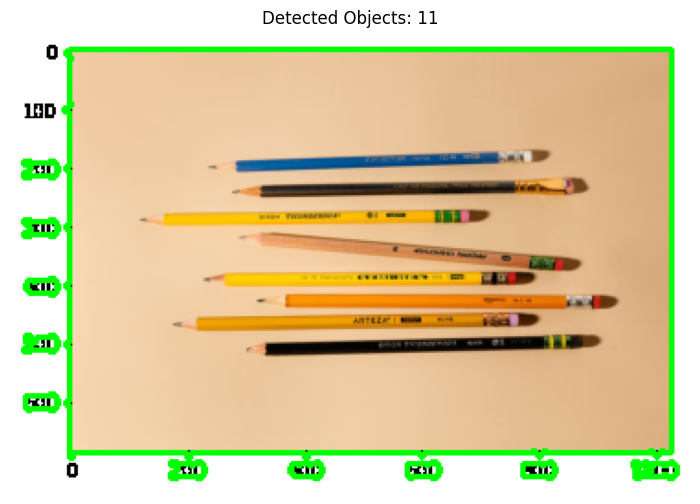

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def count_objects(image_path):
    # Read the image
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError("Image not found or cannot be read")
    
    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Apply Gaussian blur to reduce noise
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
    # Apply adaptive thresholding
    thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                 cv2.THRESH_BINARY_INV, 11, 2)
    
    # Find contours
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Filter contours by area to remove small noise
    min_area = 100  # Adjust this value based on your image
    valid_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_area]
    
    # Count the number of valid contours (objects)
    object_count = len(valid_contours)
    
    # Draw contours on the original image for visualization
    output_image = image.copy()
    cv2.drawContours(output_image, valid_contours, -1, (0, 255, 0), 2)
    
    # Save the processed image
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
    plt.title(f"Detected Objects: {object_count}")
    plt.axis('off')
    plt.savefig('output_image.png')
    
    return object_count

# Example usage
if __name__ == "__main__":
    try:
        image_path = "pencil.png"  # Replace with your image path
        count = count_objects(image_path)
        print(f"Number of objects detected: {count}")
    except Exception as e:
        print(f"Error: {e}")

In [ ]:
import cv2
import numpy as np
from skimage.feature import peak_local_max

def count_objects(binary_img, min_distance=10, threshold_rel=0.1):
    """
    Count the number of objects in a binary image, accurately separating closely spaced objects.
    
    Parameters:
    - binary_img: Binary image (numpy array) where objects are 1 (or True) and background is 0 (or False)
    - min_distance: Minimum distance between local maxima (adjust based on object size)
    - threshold_rel: Relative threshold for peak detection (adjust to filter noise)
    
    Returns:
    - num_objects: Number of objects in the image
    """
    # Ensure the image is in the correct format (uint8, 0s and 1s)
    binary_img = binary_img.astype(np.uint8)
    
    # Compute the distance transform
    dist_transform = cv2.distanceTransform(binary_img, cv2.DIST_L2, 5)
    
    # Normalize distance transform for peak detection
    dist_norm = dist_transform / np.max(dist_transform)
    
    # Find local maxima in the distance transform
    coordinates = peak_local_max(dist_norm, min_distance=min_distance, threshold_rel=threshold_rel)
    
    # Create a marker image for watershed
    markers = np.zeros_like(binary_img, dtype=np.int32)
    for i, coord in enumerate(coordinates):
        markers[coord[0], coord[1]] = i + 1  # Assign unique labels starting from 1
    
    # Prepare the inverted distance transform for watershed
    max_dist = np.max(dist_transform)
    inverted_dist = max_dist - dist_transform
    inverted_dist_norm = cv2.normalize(inverted_dist, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    inverted_dist_3c = cv2.merge([inverted_dist_norm, inverted_dist_norm, inverted_dist_norm])
    
    # Apply watershed algorithm
    cv2.watershed(inverted_dist_3c, markers)
    
    # Count unique labels, excluding -1 (watershed boundaries)
    unique_labels = np.unique(markers)
    num_objects = len(unique_labels[unique_labels > 0])
    
    return num_objects

# Example usage
if __name__ == "__main__":
    # Load an image and convert to binary (example assumes a grayscale image)
    image = cv2.imread('Unknown.jpeg', 0)  # Replace 'image.png' with your image path
    binary_img = (image > 0).astype(np.uint8)  # Threshold to binary (adjust threshold as needed)
    
    # Count objects
    num_objects = count_objects(binary_img, min_distance=10, threshold_rel=0.1)
    print(f"Number of objects: {num_objects}")

Number of objects: 0


In [7]:
import cv2 as cv
import numpy as np

# 1. Load image
img = cv.imread('pencil.png')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)  # convert to grayscale :contentReference[oaicite:0]{index=0}

# 2. Binarize via Otsu’s thresholding
ret, thresh = cv.threshold(gray, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)  # :contentReference[oaicite:1]{index=1}

# 3. Remove noise with morphological opening
kernel = np.ones((3, 3), np.uint8)
opening = cv.morphologyEx(thresh, cv.MORPH_OPEN, kernel, iterations=2)  # :contentReference[oaicite:2]{index=2}

# 4. Identify sure background by dilation
sure_bg = cv.dilate(opening, kernel, iterations=3)  # :contentReference[oaicite:3]{index=3}

# 5. Compute distance transform & threshold for sure foreground
dist_transform = cv.distanceTransform(opening, cv.DIST_L2, 5)  # :contentReference[oaicite:4]{index=4}
ret, sure_fg = cv.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)  # :contentReference[oaicite:5]{index=5}
sure_fg = np.uint8(sure_fg)

# 6. Find unknown region (boundary) by subtracting sure foreground from background
unknown = cv.subtract(sure_bg, sure_fg)  # :contentReference[oaicite:6]{index=6}

# 7. Marker labelling
ret, markers = cv.connectedComponents(sure_fg)  # initial labels :contentReference[oaicite:7]{index=7}
markers = markers + 1                            # ensure background ≠ 0 :contentReference[oaicite:8]{index=8}
markers[unknown == 255] = 0                      # mark boundary region as 0 :contentReference[oaicite:9]{index=9}

# 8. Apply watershed
markers = cv.watershed(img, markers)             # watershed segmentation :contentReference[oaicite:10]{index=10}
img[markers == -1] = [255, 0, 0]                  # outline boundaries in red :contentReference[oaicite:11]{index=11}

# 9. Count objects (unique markers minus the background)
object_count = len(np.unique(markers)) - 1
print("Number of objects detected:", object_count)


Number of objects detected: 18


In [8]:
import cv2 as cv
import numpy as np

# 1. Load image
img = cv.imread('pencil.png')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)  # convert to grayscale :contentReference[oaicite:0]{index=0}

# 2. Binarize via Otsu’s thresholding
ret, thresh = cv.threshold(gray, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)  # :contentReference[oaicite:1]{index=1}

# 3. Remove noise with morphological opening
kernel = np.ones((3, 3), np.uint8)
opening = cv.morphologyEx(thresh, cv.MORPH_OPEN, kernel, iterations=2)  # :contentReference[oaicite:2]{index=2}

# 4. Identify sure background by dilation
sure_bg = cv.dilate(opening, kernel, iterations=3)  # :contentReference[oaicite:3]{index=3}

# 5. Compute distance transform & threshold for sure foreground
dist_transform = cv.distanceTransform(opening, cv.DIST_L2, 5)  # :contentReference[oaicite:4]{index=4}
ret, sure_fg = cv.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)  # :contentReference[oaicite:5]{index=5}
sure_fg = np.uint8(sure_fg)

# 6. Find unknown region (boundary) by subtracting sure foreground from background
unknown = cv.subtract(sure_bg, sure_fg)  # :contentReference[oaicite:6]{index=6}

# 7. Marker labelling
ret, markers = cv.connectedComponents(sure_fg)  # initial labels :contentReference[oaicite:7]{index=7}
markers = markers + 1                            # ensure background ≠ 0 :contentReference[oaicite:8]{index=8}
markers[unknown == 255] = 0                      # mark boundary region as 0 :contentReference[oaicite:9]{index=9}

# 8. Apply watershed
markers = cv.watershed(img, markers)             # watershed segmentation :contentReference[oaicite:10]{index=10}
img[markers == -1] = [255, 0, 0]                  # outline boundaries in red :contentReference[oaicite:11]{index=11}

# 9. Count objects (unique markers minus the background)
object_count = len(np.unique(markers)) - 1
print("Number of objects detected:", object_count)


Number of objects detected: 18
